# Visualisation des features et synthèse des résultats

Ce notebook prépare des visualisations utiles pour le mémoire.

Objectifs :

- lire tous les CSV disponibles dans `reports/` ;
- comparer les résultats principaux déjà obtenus ;
- visualiser l'espace de features du CNN avec PCA et t-SNE ;
- vérifier visuellement si les images se regroupent plutôt par `freshness` ou par `product_type` ;
- sauvegarder les figures importantes dans `reports/figures/`.

## Préparation

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import yaml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

reports_dir = project_root / "reports"
figures_dir = reports_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

config_path = project_root / "config.yaml"
config = yaml.safe_load(config_path.read_text(encoding="utf-8"))

plt.style.use("default")
project_root

WindowsPath('c:/Users/antoc/FreshOrRotten')

In [2]:
def save_figure(filename):
    """Sauvegarde la figure courante dans reports/figures."""
    output_path = figures_dir / filename
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Figure sauvegardée : {output_path}")


def find_csv(name):
    """Retourne le premier CSV qui porte ce nom dans reports/."""
    matches = sorted(reports_dir.rglob(name))
    return matches[0] if matches else None


def read_csv_if_exists(name):
    """Charge un CSV s'il existe, sinon retourne None."""
    csv_path = find_csv(name)
    if csv_path is None:
        print(f"CSV absent : {name}")
        return None
    return pd.read_csv(csv_path)


def plot_metric_bars(dataframe, x_column, y_columns, title, ylabel, filename):
    """Trace un graphique en barres simple et sauvegardé."""
    ax = dataframe.set_index(x_column)[y_columns].plot(kind="bar", figsize=(9, 5))
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    plt.xticks(rotation=0)
    plt.tight_layout()
    save_figure(filename)
    plt.show()

## Inventaire des CSV

Cette section charge tous les CSV du dossier `reports/`, y compris les sous-dossiers.
Cela permet de vérifier quelles expériences sont disponibles avant de construire les graphiques.

In [3]:
csv_files = sorted(reports_dir.rglob("*.csv"))

csv_index = pd.DataFrame(
    [
        {
            "relative_path": csv_path.relative_to(reports_dir).as_posix(),
            "filename": csv_path.name,
            "size_kb": round(csv_path.stat().st_size / 1024, 1),
        }
        for csv_path in csv_files
    ]
)

# On charge tous les CSV pour avoir un point d'entrée unique dans le notebook.
csv_tables = {
    csv_path.relative_to(reports_dir).as_posix(): pd.read_csv(csv_path)
    for csv_path in csv_files
}

csv_index

,relative_path,filename,size_kb
0,confusion_matrix.csv,confusion_matrix.csv,0.1
1,evaluation_comparison.csv,evaluation_comparison.csv,0.3
2,evaluation_metrics.csv,evaluation_metrics.csv,0.1
3,feature_distance/feature_distance_by_product_t...,feature_distance_by_product_type.csv,6.2
4,feature_distance/feature_distance_calibration_...,feature_distance_calibration_grid.csv,51.4
5,feature_distance/feature_distance_metrics.csv,feature_distance_metrics.csv,1.1
6,hybrid/hybrid_uncertainty_by_product_type.csv,hybrid_uncertainty_by_product_type.csv,6.3
7,hybrid/hybrid_uncertainty_calibration_grid.csv,hybrid_uncertainty_calibration_grid.csv,1266.5
8,hybrid/hybrid_uncertainty_metrics.csv,hybrid_uncertainty_metrics.csv,1.1
9,product_type/product_type_probe_by_product_typ...,product_type_probe_by_product_type.csv,1.4


## Split classique vs catégories non vues

Ces graphiques résument le résultat principal : la performance baisse lorsque certaines catégories sont absentes de l'entraînement.

,protocol,loss,accuracy,precision,recall,f1_score
0,standard_split,0.253918,0.896876,0.920261,0.857479,0.887761
1,unseen_category_split,0.792450,0.670630,0.640530,0.885268,0.743271


Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\comparison_standard_vs_unseen.png


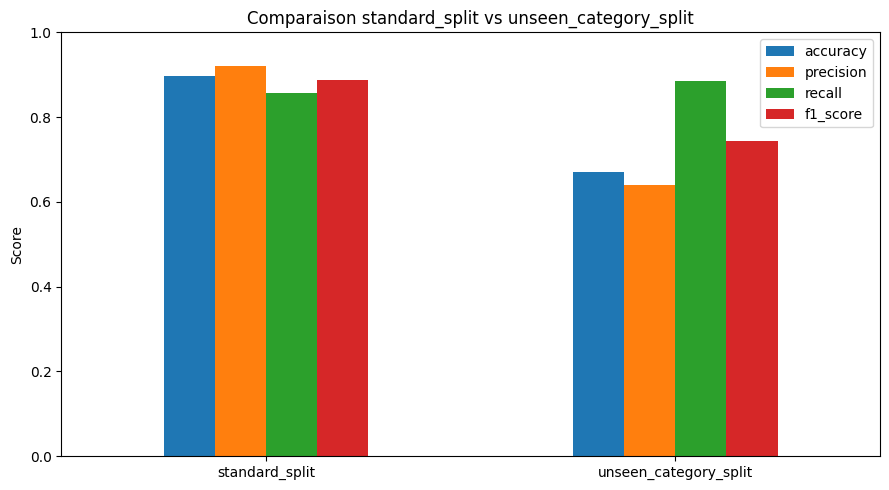

In [4]:
comparison_df = read_csv_if_exists("evaluation_comparison.csv")

if comparison_df is not None:
    display(comparison_df)
    plot_metric_bars(
        comparison_df,
        x_column="protocol",
        y_columns=["accuracy", "precision", "recall", "f1_score"],
        title="Comparaison standard_split vs unseen_category_split",
        ylabel="Score",
        filename="comparison_standard_vs_unseen.png",
    )

,product_type,image_count,accuracy,precision,recall,f1_score
0,apple,7731,0.766266,0.754772,0.853390,0.801057
1,banana,7118,0.620539,0.577212,0.937309,0.714452
2,tomato,4409,0.583806,0.591368,0.864617,0.702352


Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\unseen_metrics_by_product_type.png


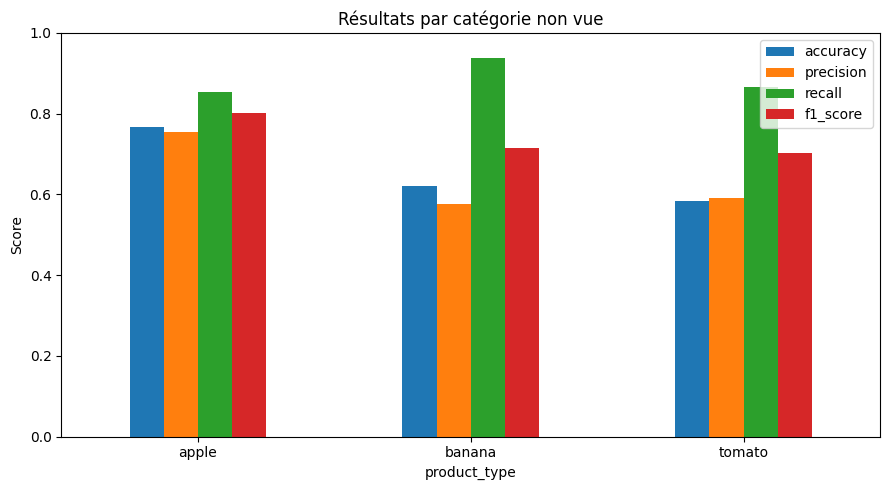

In [5]:
unseen_by_product = read_csv_if_exists("unseen_category_metrics_by_product_type.csv")

if unseen_by_product is not None:
    display(unseen_by_product)
    ax = unseen_by_product.set_index("product_type")[["accuracy", "precision", "recall", "f1_score"]].plot(
        kind="bar",
        figsize=(9, 5),
    )
    ax.set_ylim(0, 1)
    ax.set_title("Résultats par catégorie non vue")
    ax.set_ylabel("Score")
    ax.set_xlabel("product_type")
    plt.xticks(rotation=0)
    plt.tight_layout()
    save_figure("unseen_metrics_by_product_type.png")
    plt.show()

## Courbes d'entraînement

Ces courbes aident à discuter l'apprentissage et l'overfitting.

Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\training_curves_standard_split.png


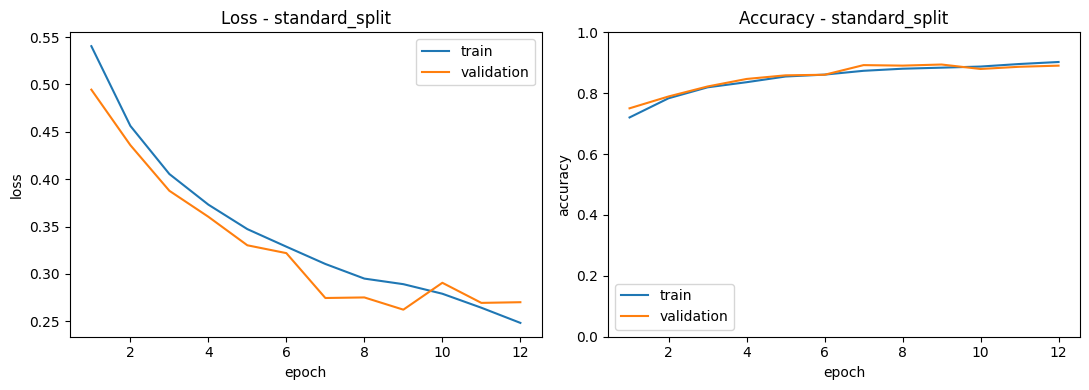

Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\training_curves_unseen_category_split.png


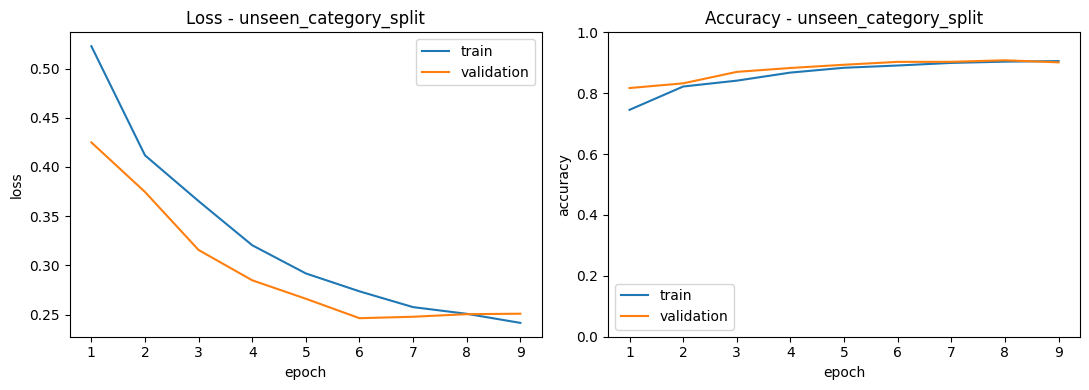

In [6]:
history_files = {
    "standard_split": "training_history.csv",
    "unseen_category_split": "unseen_training_history.csv",
}

for protocol, filename in history_files.items():
    history_df = read_csv_if_exists(filename)
    if history_df is None:
        continue

    if "epoch" not in history_df.columns:
        history_df = history_df.reset_index().rename(columns={"index": "epoch"})

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history_df["epoch"], history_df["loss"], label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="validation")
    axes[0].set_title(f"Loss - {protocol}")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["accuracy"], label="train")
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="validation")
    axes[1].set_title(f"Accuracy - {protocol}")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    plt.tight_layout()
    save_figure(f"training_curves_{protocol}.png")
    plt.show()

## Matrices de confusion fresh / rotten

Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\confusion_matrix_standard_split.png


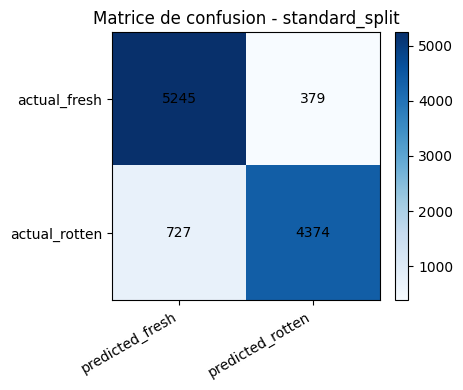

Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\confusion_matrix_unseen_category_split.png


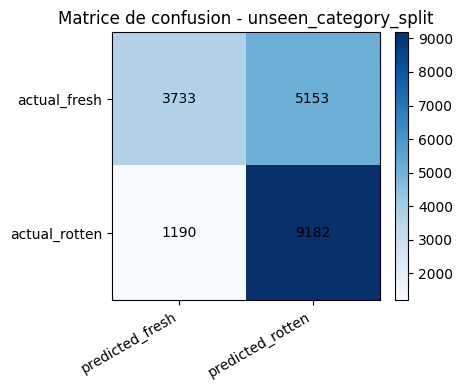

In [7]:
confusion_files = {
    "standard_split": "confusion_matrix.csv",
    "unseen_category_split": "unseen_category_confusion_matrix.csv",
}

for protocol, filename in confusion_files.items():
    csv_path = find_csv(filename)
    if csv_path is None:
        continue

    confusion_df = pd.read_csv(csv_path, index_col=0)
    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(confusion_df.values, cmap="Blues")
    ax.set_title(f"Matrice de confusion - {protocol}")
    ax.set_xticks(range(len(confusion_df.columns)))
    ax.set_xticklabels(confusion_df.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(confusion_df.index)))
    ax.set_yticklabels(confusion_df.index)

    for row_index in range(confusion_df.shape[0]):
        for column_index in range(confusion_df.shape[1]):
            ax.text(column_index, row_index, int(confusion_df.iloc[row_index, column_index]), ha="center", va="center")

    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    save_figure(f"confusion_matrix_{protocol}.png")
    plt.show()

## Méthodes d'incertitude

On compare le seuil sigmoid, la distance de features et la règle hybride.

,method,protocol,baseline_accuracy,accepted_accuracy,coverage,uncertain_rate,uncertain_error_rate
0,sigmoid_0.90,standard,0.896876,0.907221,0.974825,0.025175,0.503704
1,sigmoid_0.90,unseen,0.670630,0.670630,1.000000,0.000000,NaN
2,sigmoid_0.95,standard,0.896876,0.955490,0.789744,0.210256,0.323282
3,sigmoid_0.95,unseen,0.670630,0.739789,0.723388,0.276612,0.510231
4,feature_distance,standard,0.896876,0.915115,0.500886,0.499114,0.121427
5,feature_distance,unseen,0.670630,0.699208,0.452643,0.547357,0.353003
6,hybrid,standard,0.896876,0.955485,0.789650,0.210350,0.323138
7,hybrid,unseen,0.670630,0.739752,0.723284,0.276716,0.510039


Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\uncertainty_methods_standard.png


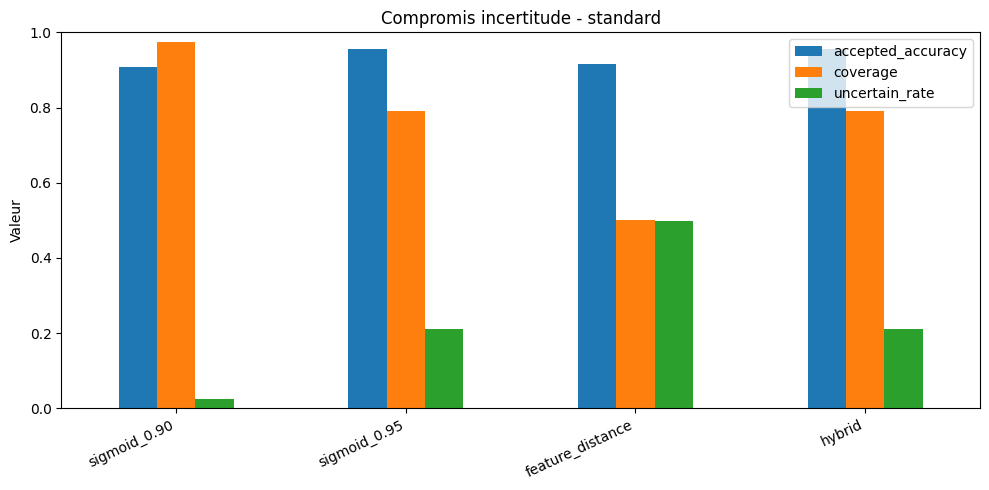

Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\uncertainty_methods_unseen.png


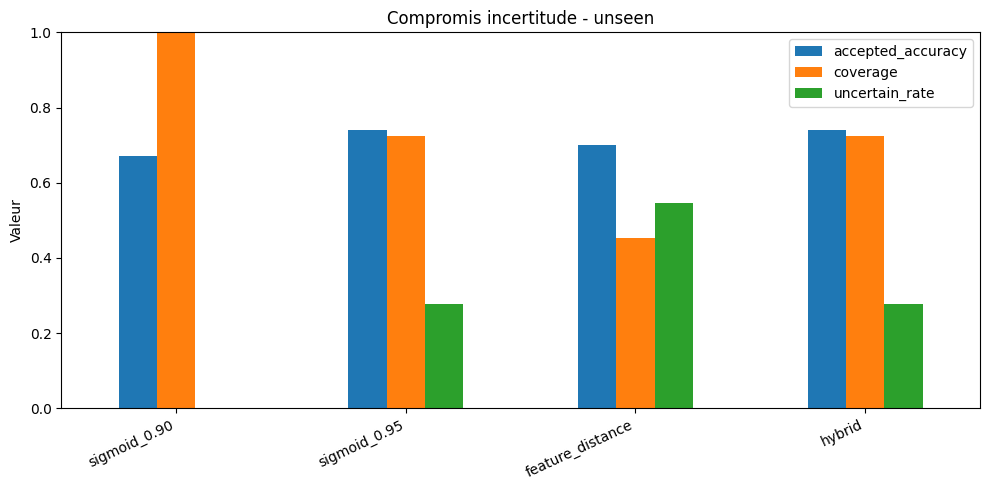

In [8]:
method_sources = [
    ("sigmoid_0.90", "target_accuracy=0.90/uncertainty_metrics.csv"),
    ("sigmoid_0.95", "target_accuracy=0.95/uncertainty_metrics.csv"),
    ("feature_distance", "feature_distance/feature_distance_metrics.csv"),
    ("hybrid", "hybrid/hybrid_uncertainty_metrics.csv"),
]

method_frames = []
for method_name, relative_path in method_sources:
    csv_path = reports_dir / relative_path
    if not csv_path.exists():
        print(f"Fichier absent : {relative_path}")
        continue
    method_df = pd.read_csv(csv_path)
    method_df.insert(0, "method", method_name)
    method_frames.append(method_df)

uncertainty_comparison = pd.concat(method_frames, ignore_index=True, sort=False)
display(uncertainty_comparison[["method", "protocol", "baseline_accuracy", "accepted_accuracy", "coverage", "uncertain_rate", "uncertain_error_rate"]])

for protocol in uncertainty_comparison["protocol"].unique():
    protocol_df = uncertainty_comparison[uncertainty_comparison["protocol"] == protocol]
    ax = protocol_df.set_index("method")[["accepted_accuracy", "coverage", "uncertain_rate"]].plot(
        kind="bar",
        figsize=(10, 5),
    )
    ax.set_ylim(0, 1)
    ax.set_title(f"Compromis incertitude - {protocol}")
    ax.set_ylabel("Valeur")
    ax.set_xlabel("")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    save_figure(f"uncertainty_methods_{protocol}.png")
    plt.show()

## Calibration et compromis accuracy / coverage

Ces graphiques montrent comment le seuil d'incertitude change la couverture et l'accuracy des prédictions acceptées.

Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\calibration_tradeoff_sigmoid_0.95.png


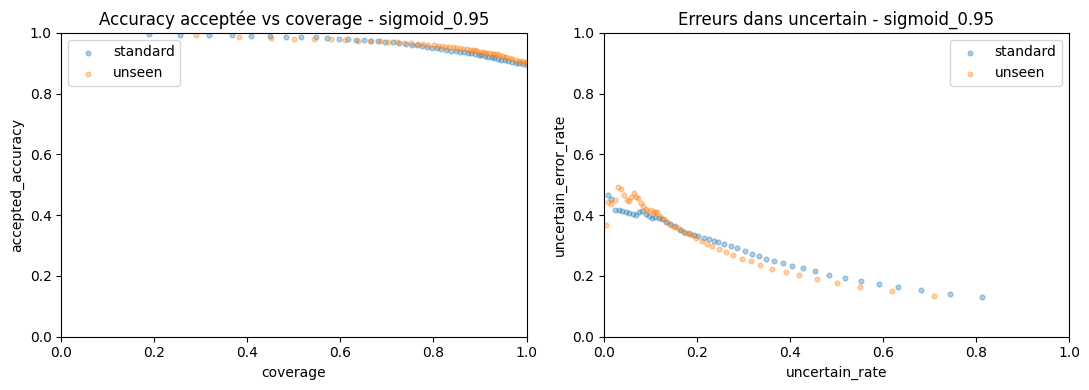

Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\calibration_tradeoff_feature_distance.png


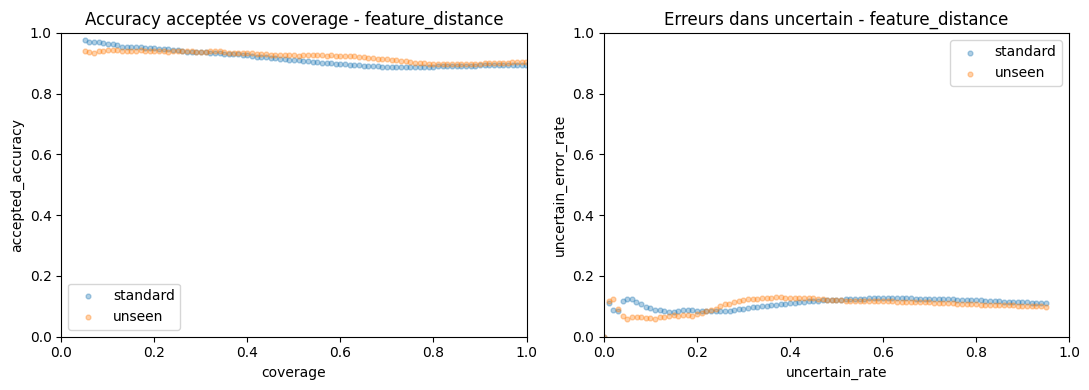

Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\calibration_tradeoff_hybrid.png


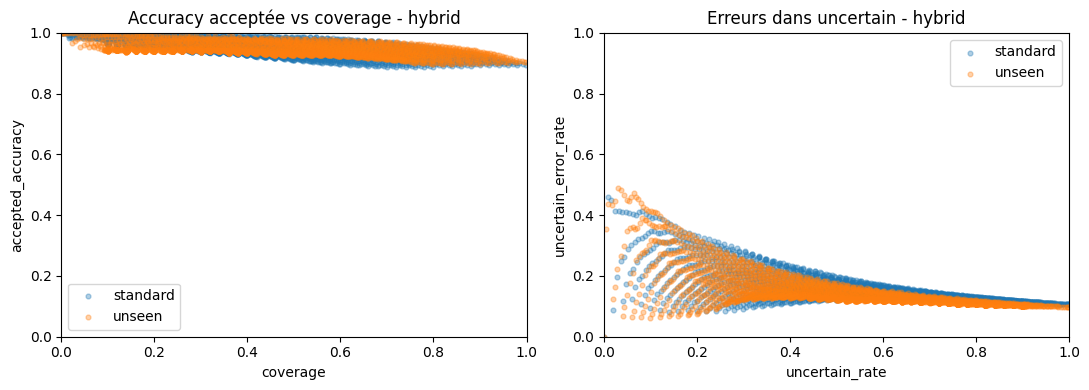

In [9]:
calibration_sources = [
    ("sigmoid_0.95", "target_accuracy=0.95/uncertainty_calibration_grid.csv"),
    ("feature_distance", "feature_distance/feature_distance_calibration_grid.csv"),
    ("hybrid", "hybrid/hybrid_uncertainty_calibration_grid.csv"),
]

for method_name, relative_path in calibration_sources:
    csv_path = reports_dir / relative_path
    if not csv_path.exists():
        continue
    calibration_df = pd.read_csv(csv_path)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for protocol, protocol_df in calibration_df.groupby("protocol"):
        axes[0].scatter(protocol_df["coverage"], protocol_df["accepted_accuracy"], s=12, alpha=0.35, label=protocol)
        axes[1].scatter(protocol_df["uncertain_rate"], protocol_df["uncertain_error_rate"], s=12, alpha=0.35, label=protocol)

    axes[0].set_title(f"Accuracy acceptée vs coverage - {method_name}")
    axes[0].set_xlabel("coverage")
    axes[0].set_ylabel("accepted_accuracy")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].legend()

    axes[1].set_title(f"Erreurs dans uncertain - {method_name}")
    axes[1].set_xlabel("uncertain_rate")
    axes[1].set_ylabel("uncertain_error_rate")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    plt.tight_layout()
    save_figure(f"calibration_tradeoff_{method_name}.png")
    plt.show()

## Biais product_type

Ces graphiques utilisent le linear probe déjà calculé pour montrer que les features du CNN encodent fortement le type du produit.

,feature_layer_index,split,image_count,product_type_count,majority_product_type,majority_baseline_accuracy,accuracy,balanced_accuracy,macro_f1_score,weighted_f1_score
0,-3,validation,10725,22,apple,0.141259,0.655012,0.776406,0.692321,0.663590
1,-3,test,10725,22,apple,0.145548,0.659301,0.780583,0.696510,0.668254


Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\product_type_probe_global_metrics.png


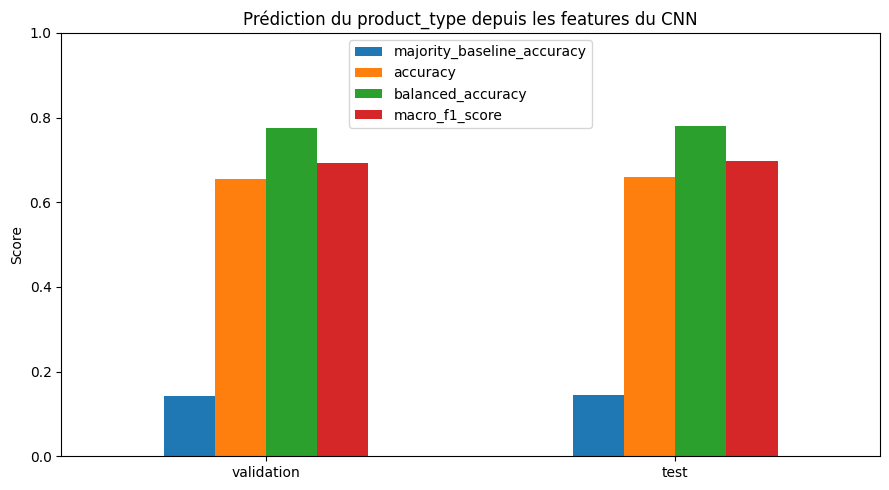

,product_type,precision,recall,f1_score,support
18,potato,0.309524,0.595833,0.407407,240
12,mango,0.312057,0.637681,0.419048,207
4,carrot,0.335784,0.640187,0.440514,214
19,strawberry,0.356678,0.649852,0.460568,337
9,jujube,0.325581,0.848485,0.470588,66
0,apple,0.691626,0.449712,0.545031,1561
8,guava,0.530233,0.629834,0.575758,543
5,cucumber,0.517060,0.766537,0.617555,257
13,orange,0.750813,0.539300,0.627717,1285
11,lime,0.571205,0.798687,0.666058,457


Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\product_type_probe_f1_by_product.png


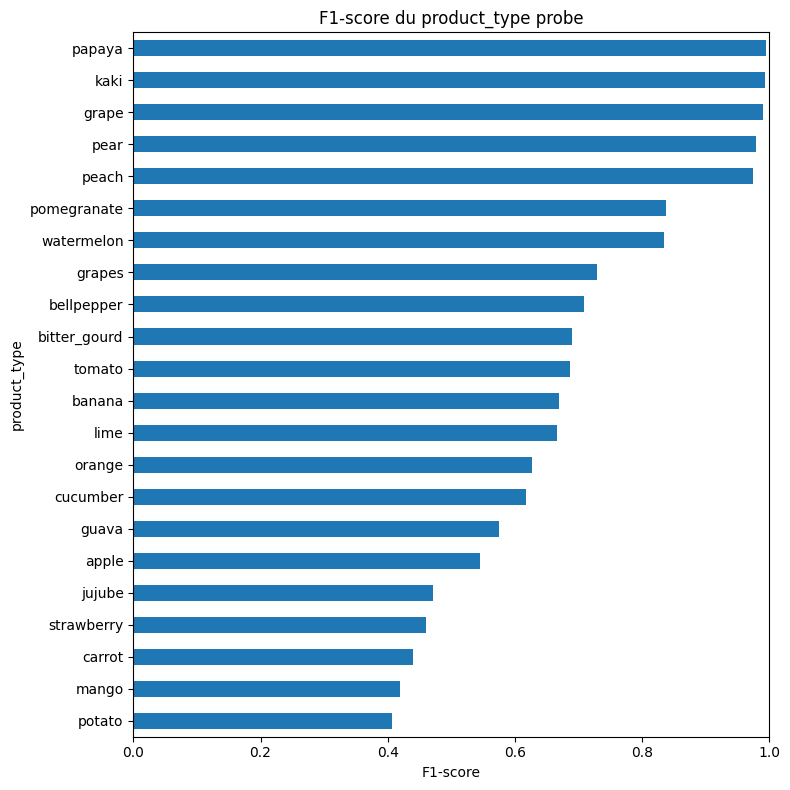

In [10]:
probe_metrics = read_csv_if_exists("product_type_probe_metrics.csv")
probe_by_product = read_csv_if_exists("product_type_probe_by_product_type.csv")

if probe_metrics is not None:
    display(probe_metrics)
    plot_metric_bars(
        probe_metrics,
        x_column="split",
        y_columns=["majority_baseline_accuracy", "accuracy", "balanced_accuracy", "macro_f1_score"],
        title="Prédiction du product_type depuis les features du CNN",
        ylabel="Score",
        filename="product_type_probe_global_metrics.png",
    )

if probe_by_product is not None:
    display(probe_by_product.sort_values("f1_score"))
    ax = probe_by_product.sort_values("f1_score").plot(
        x="product_type",
        y="f1_score",
        kind="barh",
        figsize=(8, 8),
        legend=False,
    )
    ax.set_xlim(0, 1)
    ax.set_title("F1-score du product_type probe")
    ax.set_xlabel("F1-score")
    ax.set_ylabel("product_type")
    plt.tight_layout()
    save_figure("product_type_probe_f1_by_product.png")
    plt.show()

## Extraction des features du CNN

On extrait les features internes du modèle baseline sur un échantillon du `test_set` standard.
L'échantillon limite le coût de t-SNE.

In [11]:
from feature_distance_uncertainty import build_feature_extractor
from feature_product_type_analysis import load_standard_sets
from train import create_image_dataset, get_image_size
from uncertainty import get_protocol_settings

visualization_config = config.get("feature_visualization", {})
training_config = config["training"]

feature_layer_index = int(visualization_config.get("feature_layer_index", -3))
max_images = int(visualization_config.get("max_images", 3000))
random_seed = int(training_config.get("random_seed", 42))
batch_size = int(training_config.get("batch_size", 32))
image_size = get_image_size(config)

training_set, validation_set, test_set = load_standard_sets(config)

sample_fraction = min(1.0, max_images / len(test_set))
# On échantillonne par produit et fraîcheur pour garder une vue équilibrée.
sampled_set = (
    test_set.groupby(["product_type", "freshness"], group_keys=False)
    .sample(frac=sample_fraction, random_state=random_seed)
    .reset_index(drop=True)
)

if len(sampled_set) > max_images:
    sampled_set = sampled_set.sample(n=max_images, random_state=random_seed).reset_index(drop=True)

protocol_settings = get_protocol_settings(config, protocol="standard")
model = tf.keras.models.load_model(protocol_settings["model_path"])
feature_extractor = build_feature_extractor(model, feature_layer_index)

dataset = create_image_dataset(
    sampled_set,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False,
    random_seed=random_seed,
)

features = feature_extractor.predict(dataset, verbose=0)
prediction_scores = model.predict(dataset, verbose=0).reshape(-1)

feature_metadata = sampled_set.reset_index(drop=True).copy()
feature_metadata["prediction_score"] = prediction_scores
feature_metadata["predicted_label"] = np.where(prediction_scores >= 0.5, "rotten", "fresh")
feature_metadata["is_correct"] = feature_metadata["predicted_label"] == feature_metadata["freshness"]

print("Images visualisées :", len(feature_metadata))
print("Dimension des features :", features.shape[1])

Images visualisées : 3000
Dimension des features : 64


## PCA des features

In [12]:
scaled_features = StandardScaler().fit_transform(features)

pca_model = PCA(n_components=2, random_state=random_seed)
pca_coordinates = pca_model.fit_transform(scaled_features)

projection_df = feature_metadata.copy()
projection_df["pca_1"] = pca_coordinates[:, 0]
projection_df["pca_2"] = pca_coordinates[:, 1]

print("Variance expliquée PCA :", pca_model.explained_variance_ratio_.round(4))
projection_df.head()

Variance expliquée PCA : [0.3825 0.1771]


,image_path,product_type,freshness,label,split,prediction_score,predicted_label,is_correct,pca_1,pca_2
0,C:\Users\antoc\FreshOrRotten\data\raw\Pomegran...,pomegranate,fresh,0,test,0.086251,fresh,True,2.491917,0.816120
1,C:\Users\antoc\FreshOrRotten\data\raw\Tomato_R...,tomato,rotten,1,test,0.161152,fresh,False,1.632529,-2.384768
2,C:\Users\antoc\FreshOrRotten\data\raw\Guava_Ro...,guava,rotten,1,test,0.920001,rotten,True,-3.545003,-2.462327
3,C:\Users\antoc\FreshOrRotten\data\raw\Apple_Ro...,apple,rotten,1,test,0.714077,rotten,True,-1.746000,-2.666614
4,C:\Users\antoc\FreshOrRotten\data\raw\Banana_R...,banana,rotten,1,test,0.997672,rotten,True,-7.755898,2.312535


Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\feature_pca_by_freshness.png


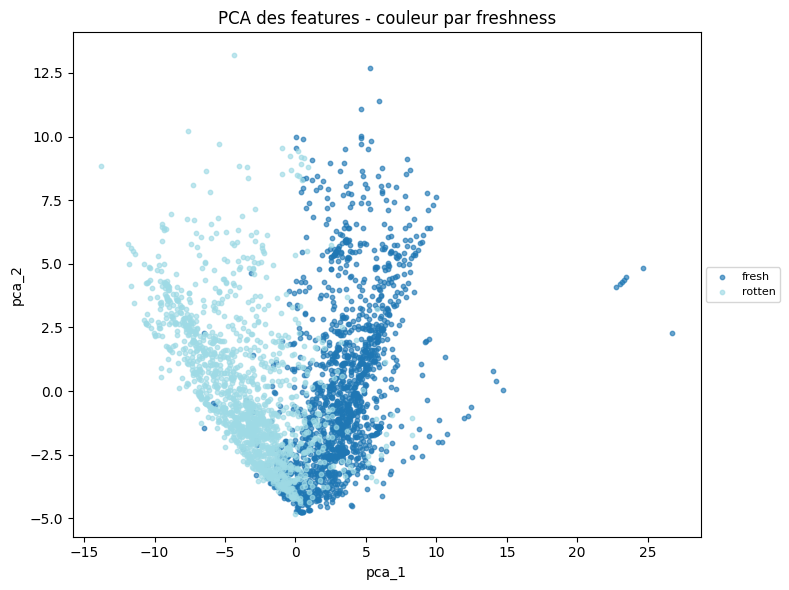

Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\feature_pca_by_product_type.png


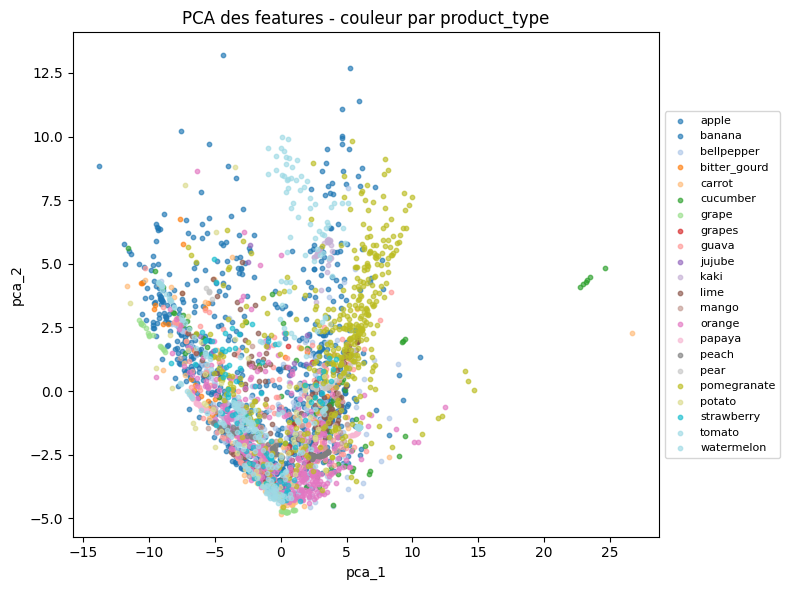

In [13]:
def scatter_by_category(dataframe, x_column, y_column, category_column, title, filename, max_legend_items=25):
    """Trace une projection 2D colorée par catégorie."""
    categories = sorted(dataframe[category_column].astype(str).unique())
    cmap = plt.get_cmap("tab20", max(len(categories), 1))

    fig, ax = plt.subplots(figsize=(8, 6))
    for index, category in enumerate(categories):
        category_df = dataframe[dataframe[category_column].astype(str) == category]
        ax.scatter(
            category_df[x_column],
            category_df[y_column],
            s=10,
            alpha=0.65,
            color=cmap(index),
            label=category,
        )

    ax.set_title(title)
    ax.set_xlabel(x_column)
    ax.set_ylabel(y_column)
    if len(categories) <= max_legend_items:
        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.tight_layout()
    save_figure(filename)
    plt.show()


scatter_by_category(
    projection_df,
    "pca_1",
    "pca_2",
    "freshness",
    "PCA des features - couleur par freshness",
    "feature_pca_by_freshness.png",
)

scatter_by_category(
    projection_df,
    "pca_1",
    "pca_2",
    "product_type",
    "PCA des features - couleur par product_type",
    "feature_pca_by_product_type.png",
)

Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\feature_pca_by_prediction_correctness.png


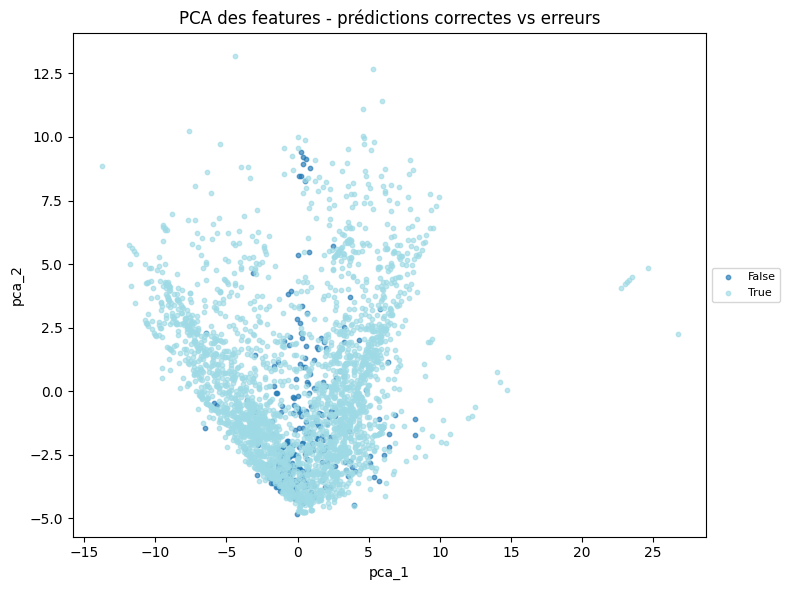

In [14]:
scatter_by_category(
    projection_df,
    "pca_1",
    "pca_2",
    "is_correct",
    "PCA des features - prédictions correctes vs erreurs",
    "feature_pca_by_prediction_correctness.png",
    max_legend_items=5,
)

## t-SNE des features

t-SNE donne une visualisation non linéaire. Elle est utile pour observer les groupes, mais elle ne doit pas être interprétée comme une distance globale exacte.

In [15]:
pca_dimension = min(30, scaled_features.shape[1], scaled_features.shape[0] - 1)
features_for_tsne = PCA(n_components=pca_dimension, random_state=random_seed).fit_transform(scaled_features)

perplexity = int(visualization_config.get("tsne_perplexity", 30))
perplexity = min(perplexity, max(5, (len(features_for_tsne) - 1) // 3))
learning_rate = visualization_config.get("tsne_learning_rate", "auto")
max_iter = int(visualization_config.get("tsne_iterations", 1000))

tsne_parameters = {
    "n_components": 2,
    "perplexity": perplexity,
    "learning_rate": learning_rate,
    "init": "pca",
    "random_state": random_seed,
}

# Selon la version de scikit-learn, le paramètre peut s'appeler max_iter ou n_iter.
if "max_iter" in TSNE().get_params():
    tsne_parameters["max_iter"] = max_iter
else:
    tsne_parameters["n_iter"] = max_iter

tsne_model = TSNE(**tsne_parameters)
tsne_coordinates = tsne_model.fit_transform(features_for_tsne)

projection_df["tsne_1"] = tsne_coordinates[:, 0]
projection_df["tsne_2"] = tsne_coordinates[:, 1]

projection_output = reports_dir / "feature_space_projection.csv"
projection_df.to_csv(projection_output, index=False)
print(f"Projection sauvegardée : {projection_output}")

Projection sauvegardée : c:\Users\antoc\FreshOrRotten\reports\feature_space_projection.csv


Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\feature_tsne_by_freshness.png


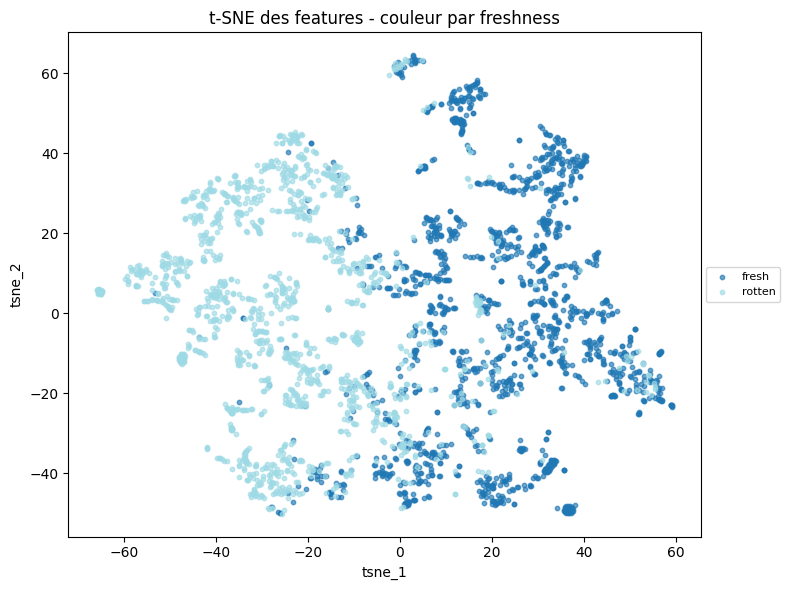

Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\feature_tsne_by_product_type.png


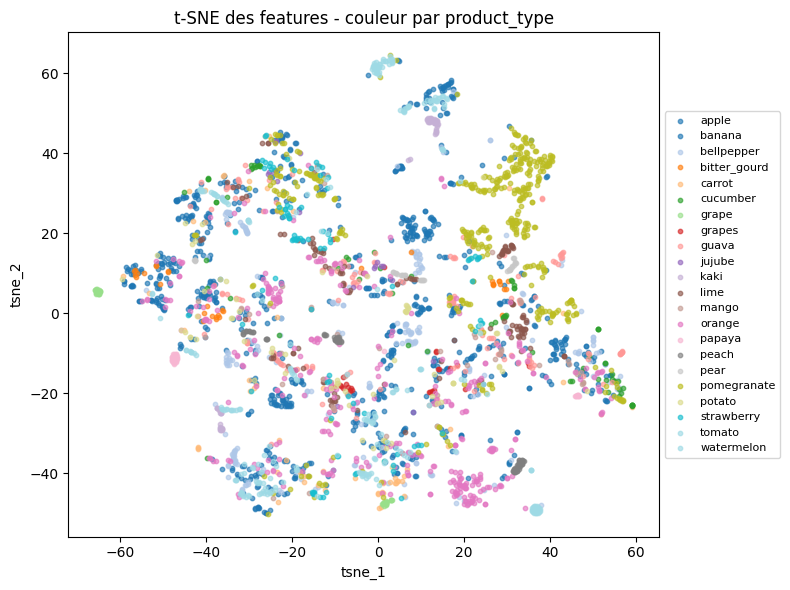

Figure sauvegardée : c:\Users\antoc\FreshOrRotten\reports\figures\feature_tsne_by_prediction_correctness.png


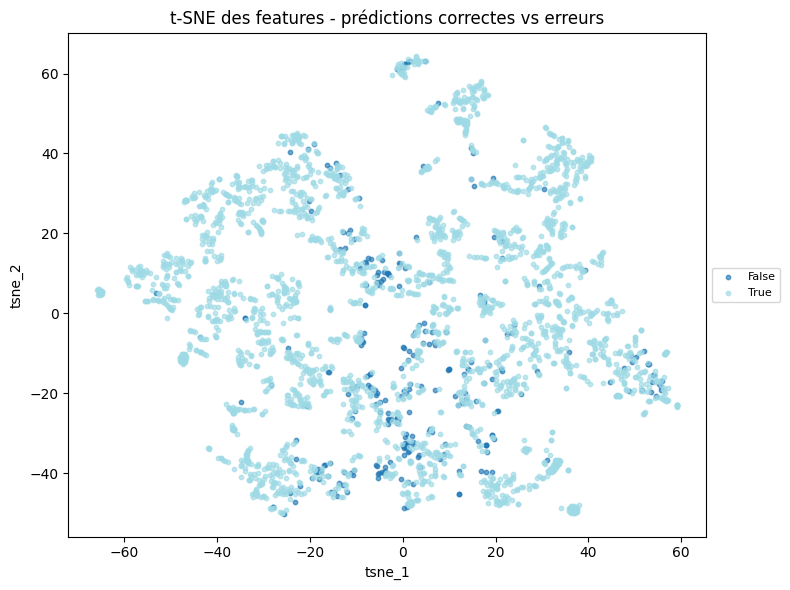

In [16]:
scatter_by_category(
    projection_df,
    "tsne_1",
    "tsne_2",
    "freshness",
    "t-SNE des features - couleur par freshness",
    "feature_tsne_by_freshness.png",
)

scatter_by_category(
    projection_df,
    "tsne_1",
    "tsne_2",
    "product_type",
    "t-SNE des features - couleur par product_type",
    "feature_tsne_by_product_type.png",
)

scatter_by_category(
    projection_df,
    "tsne_1",
    "tsne_2",
    "is_correct",
    "t-SNE des features - prédictions correctes vs erreurs",
    "feature_tsne_by_prediction_correctness.png",
    max_legend_items=5,
)

## Méthode product_type-invariant

Cette section compare la baseline CNN avec la variante qui cherche à réduire la dépendance au `product_type`. Les figures servent à montrer trois points : l'effet sur la performance fresh/rotten, l'effet sur la généralisation aux catégories non vues et l'effet sur la quantité d'information `product_type` encore présente dans les features.


In [ ]:
def read_report_csv(relative_path):
    """Charge un CSV depuis reports/ avec un chemin explicite."""
    csv_path = reports_dir / relative_path
    if not csv_path.exists():
        print(f"CSV absent : {csv_path}")
        return None
    return pd.read_csv(csv_path)


def add_value_labels(ax, fmt="{:.3f}"):
    """Ajoute les valeurs au-dessus des barres."""
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            if np.isnan(value):
                labels.append("")
            else:
                labels.append(fmt.format(value))
        ax.bar_label(container, labels=labels, fontsize=8, padding=2)


def prettify_metric_axis(ax, title, ylabel="Score"):
    """Applique une mise en forme commune aux graphiques de metriques."""
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)


In [ ]:
method_comparison = read_report_csv("product_type_invariant/product_type_invariant_comparison.csv")

if method_comparison is not None:
    display(method_comparison)

    metrics = ["accuracy", "precision", "recall", "f1_score"]
    methods = ["baseline_cnn", "product_type_invariant_cnn"]
    protocols = ["standard_split", "unseen_category_split"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    for ax, protocol in zip(axes, protocols):
        protocol_df = method_comparison[method_comparison["protocol"] == protocol]
        plot_df = protocol_df.set_index("method").loc[methods, metrics]
        plot_df.index = ["baseline", "invariant"]
        plot_df.plot(kind="bar", ax=ax, width=0.78)
        prettify_metric_axis(ax, protocol)
        ax.tick_params(axis="x", rotation=0)
        add_value_labels(ax)
        ax.legend(loc="lower right", fontsize=8)

    fig.suptitle("Baseline CNN vs methode product_type-invariant", y=1.04)
    plt.tight_layout()
    save_figure("product_type_invariant_metric_comparison.png")
    plt.show()


In [ ]:
if method_comparison is not None:
    metrics = ["accuracy", "precision", "recall", "f1_score"]
    delta_rows = []

    for protocol in method_comparison["protocol"].unique():
        protocol_df = method_comparison[method_comparison["protocol"] == protocol].set_index("method")
        if {"baseline_cnn", "product_type_invariant_cnn"}.issubset(protocol_df.index):
            row = {"protocol": protocol}
            for metric in metrics:
                row[metric] = protocol_df.loc["product_type_invariant_cnn", metric] - protocol_df.loc["baseline_cnn", metric]
            delta_rows.append(row)

    delta_df = pd.DataFrame(delta_rows)
    display(delta_df)

    ax = delta_df.set_index("protocol")[metrics].plot(kind="bar", figsize=(10, 4.5), width=0.78)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("Ecart invariant - baseline")
    ax.set_ylabel("Difference de score")
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=0)
    add_value_labels(ax, fmt="{:+.3f}")
    plt.tight_layout()
    save_figure("product_type_invariant_metric_delta.png")
    plt.show()


In [ ]:
baseline_unseen_by_product = read_report_csv("unseen_category_metrics_by_product_type.csv")
invariant_unseen_by_product = read_report_csv("product_type_invariant/product_type_invariant_unseen_metrics_by_product_type.csv")

if baseline_unseen_by_product is not None and invariant_unseen_by_product is not None:
    baseline_tmp = baseline_unseen_by_product.copy()
    invariant_tmp = invariant_unseen_by_product.copy()
    baseline_tmp["method"] = "baseline"
    invariant_tmp["method"] = "invariant"
    unseen_product_comparison = pd.concat([baseline_tmp, invariant_tmp], ignore_index=True)
    display(unseen_product_comparison)

    metrics = ["accuracy", "precision", "recall", "f1_score"]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
    for ax, metric in zip(axes.ravel(), metrics):
        pivot_df = unseen_product_comparison.pivot(index="product_type", columns="method", values=metric)
        pivot_df = pivot_df[["baseline", "invariant"]]
        pivot_df.plot(kind="bar", ax=ax, width=0.75)
        prettify_metric_axis(ax, metric)
        ax.tick_params(axis="x", rotation=0)
        add_value_labels(ax)
        ax.legend(fontsize=8)

    fig.suptitle("Resultats par categorie non vue", y=1.02)
    plt.tight_layout()
    save_figure("product_type_invariant_unseen_by_product_type.png")
    plt.show()


In [ ]:
if baseline_unseen_by_product is not None and invariant_unseen_by_product is not None:
    baseline_indexed = baseline_unseen_by_product.set_index("product_type")
    invariant_indexed = invariant_unseen_by_product.set_index("product_type")
    common_products = sorted(set(baseline_indexed.index) & set(invariant_indexed.index))
    delta_by_product = pd.DataFrame(index=common_products)

    for metric in ["accuracy", "precision", "recall", "f1_score"]:
        delta_by_product[metric] = invariant_indexed.loc[common_products, metric] - baseline_indexed.loc[common_products, metric]

    display(delta_by_product.reset_index().rename(columns={"index": "product_type"}))

    ax = delta_by_product[["accuracy", "f1_score"]].plot(kind="bar", figsize=(9, 4.5), width=0.72)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("Gain ou perte par categorie non vue")
    ax.set_ylabel("Difference de score")
    ax.set_xlabel("product_type")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=0)
    add_value_labels(ax, fmt="{:+.3f}")
    plt.tight_layout()
    save_figure("product_type_invariant_unseen_delta_by_product_type.png")
    plt.show()


In [ ]:
baseline_probe_metrics = read_report_csv("product_type_probe_baseline/product_type_probe_metrics.csv")
invariant_probe_metrics = read_report_csv("product_type_probe_invariant/product_type_probe_metrics.csv")

if baseline_probe_metrics is not None and invariant_probe_metrics is not None:
    baseline_probe_tmp = baseline_probe_metrics.copy()
    invariant_probe_tmp = invariant_probe_metrics.copy()
    baseline_probe_tmp["method"] = "baseline"
    invariant_probe_tmp["method"] = "invariant"
    probe_comparison = pd.concat([baseline_probe_tmp, invariant_probe_tmp], ignore_index=True)
    display(probe_comparison)

    probe_test = probe_comparison[probe_comparison["split"] == "test"]
    metrics = ["accuracy", "balanced_accuracy", "macro_f1_score", "weighted_f1_score"]
    plot_df = probe_test.set_index("method")[metrics].loc[["baseline", "invariant"]]

    ax = plot_df.plot(kind="bar", figsize=(9, 4.5), width=0.75)
    prettify_metric_axis(ax, "Sonde product_type sur les features de test")
    plt.xticks(rotation=0)
    add_value_labels(ax)
    plt.tight_layout()
    save_figure("product_type_probe_baseline_vs_invariant.png")
    plt.show()


In [ ]:
baseline_probe_by_product = read_report_csv("product_type_probe_baseline/product_type_probe_by_product_type.csv")
invariant_probe_by_product = read_report_csv("product_type_probe_invariant/product_type_probe_by_product_type.csv")

if baseline_probe_by_product is not None and invariant_probe_by_product is not None:
    baseline_indexed = baseline_probe_by_product.set_index("product_type")
    invariant_indexed = invariant_probe_by_product.set_index("product_type")
    common_products = sorted(set(baseline_indexed.index) & set(invariant_indexed.index))

    probe_product_df = pd.DataFrame({
        "baseline": baseline_indexed.loc[common_products, "f1_score"],
        "invariant": invariant_indexed.loc[common_products, "f1_score"],
    })
    probe_product_df["delta"] = probe_product_df["invariant"] - probe_product_df["baseline"]
    probe_product_df = probe_product_df.sort_values("delta")
    display(probe_product_df.reset_index())

    ax = probe_product_df[["baseline", "invariant"]].plot(kind="barh", figsize=(9, 8), width=0.76)
    ax.set_xlim(0, 1)
    ax.set_title("F1-score du probe product_type par produit")
    ax.set_xlabel("F1-score")
    ax.set_ylabel("product_type")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    save_figure("product_type_probe_f1_by_product_baseline_vs_invariant.png")
    plt.show()


In [ ]:
def plot_invariant_history(history_df, protocol, axes):
    """Trace loss et accuracy freshness pour un historique invariant."""
    if history_df is None:
        return

    if "epoch" not in history_df.columns:
        history_df = history_df.reset_index().rename(columns={"index": "epoch"})

    axes[0].plot(history_df["epoch"], history_df["freshness_loss"], label=f"train {protocol}")
    axes[0].plot(history_df["epoch"], history_df["val_freshness_loss"], linestyle="--", label=f"validation {protocol}")

    axes[1].plot(history_df["epoch"], history_df["freshness_accuracy"], label=f"train {protocol}")
    axes[1].plot(history_df["epoch"], history_df["val_freshness_accuracy"], linestyle="--", label=f"validation {protocol}")

    axes[2].plot(history_df["epoch"], history_df["product_type_accuracy"], label=f"train {protocol}")
    axes[2].plot(history_df["epoch"], history_df["val_product_type_accuracy"], linestyle="--", label=f"validation {protocol}")


standard_invariant_history = read_report_csv("product_type_invariant/product_type_invariant_history.csv")
unseen_invariant_history = read_report_csv("product_type_invariant/product_type_invariant_unseen_history.csv")

if standard_invariant_history is not None or unseen_invariant_history is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    plot_invariant_history(standard_invariant_history, "standard", axes)
    plot_invariant_history(unseen_invariant_history, "unseen", axes)

    axes[0].set_title("Freshness loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].grid(alpha=0.25)

    axes[1].set_title("Freshness accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.25)

    axes[2].set_title("Product_type accuracy adversariale")
    axes[2].set_xlabel("epoch")
    axes[2].set_ylabel("accuracy")
    axes[2].set_ylim(0, 1)
    axes[2].grid(alpha=0.25)

    for ax in axes:
        ax.legend(fontsize=8)

    fig.suptitle("Courbes d'entrainement du modele product_type-invariant", y=1.03)
    plt.tight_layout()
    save_figure("product_type_invariant_training_curves.png")
    plt.show()


In [ ]:
def load_confusion_matrix(relative_path):
    """Charge une matrice de confusion avec la premiere colonne comme index."""
    csv_path = reports_dir / relative_path
    if not csv_path.exists():
        print(f"CSV absent : {csv_path}")
        return None
    return pd.read_csv(csv_path, index_col=0)


def draw_confusion_matrix(ax, confusion_df, title):
    """Affiche une matrice de confusion dans un axe matplotlib."""
    values = confusion_df.values
    ax.imshow(values, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(range(len(confusion_df.columns)))
    ax.set_xticklabels(confusion_df.columns, rotation=25, ha="right")
    ax.set_yticks(range(len(confusion_df.index)))
    ax.set_yticklabels(confusion_df.index)

    text_threshold = values.max() / 2
    for row_index in range(confusion_df.shape[0]):
        for column_index in range(confusion_df.shape[1]):
            value = int(confusion_df.iloc[row_index, column_index])
            text_color = "white" if value > text_threshold else "black"
            ax.text(
                column_index,
                row_index,
                value,
                ha="center",
                va="center",
                fontsize=10,
                color=text_color,
            )


confusion_sources = {
    "Baseline standard": "confusion_matrix.csv",
    "Invariant standard": "product_type_invariant/product_type_invariant_standard_confusion_matrix.csv",
    "Baseline unseen": "unseen_category_confusion_matrix.csv",
    "Invariant unseen": "product_type_invariant/product_type_invariant_unseen_confusion_matrix.csv",
}

confusion_matrices = {title: load_confusion_matrix(path) for title, path in confusion_sources.items()}
if all(matrix is not None for matrix in confusion_matrices.values()):
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.2), constrained_layout=True)
    for ax, (title, confusion_df) in zip(axes.ravel(), confusion_matrices.items()):
        draw_confusion_matrix(ax, confusion_df, title)

    fig.suptitle("Matrices de confusion baseline vs methode product_type-invariant", y=1.02)
    save_figure("product_type_invariant_confusion_matrices.png")
    plt.show()


In [ ]:
baseline_unseen_confusion = load_confusion_matrix("unseen_category_confusion_matrix.csv")
invariant_unseen_confusion = load_confusion_matrix("product_type_invariant/product_type_invariant_unseen_confusion_matrix.csv")

if baseline_unseen_confusion is not None and invariant_unseen_confusion is not None:
    error_rows = []
    for method_name, confusion_df in {
        "baseline": baseline_unseen_confusion,
        "invariant": invariant_unseen_confusion,
    }.items():
        error_rows.append({
            "method": method_name,
            "fresh -> rotten": int(confusion_df.loc["actual_fresh", "predicted_rotten"]),
            "rotten -> fresh": int(confusion_df.loc["actual_rotten", "predicted_fresh"]),
        })

    unseen_error_df = pd.DataFrame(error_rows).set_index("method")
    display(unseen_error_df)

    ax = unseen_error_df.plot(kind="bar", figsize=(8, 4.6), width=0.72)
    ax.set_title("Types d'erreurs sur le unseen_category_split")
    ax.set_ylabel("Nombre d'images mal classees")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    add_value_labels(ax, fmt="{:.0f}")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    save_figure("product_type_invariant_unseen_error_types.png")
    plt.show()


## Sweep du poids adversarial

Cette section exploite les rapports g?n?r?s dans `reports/product_type_invariant_sweep/`.
Elle compare plusieurs poids adversariaux pour la m?thode `product_type`-invariant.
Les figures servent ? discuter le compromis entre performance classique, g?n?ralisation aux cat?gories non vues et r?duction de l'information `product_type` dans les features.

In [ ]:
sweep_summary = read_report_csv("product_type_invariant_sweep/product_type_invariant_sweep_summary.csv")
baseline_comparison = read_report_csv("evaluation_comparison.csv")

if sweep_summary is not None and baseline_comparison is not None:
    protocol_map = {
        "standard_split": "standard",
        "unseen_category_split": "unseen",
    }
    baseline_rows = baseline_comparison.copy()
    baseline_rows["protocol"] = baseline_rows["protocol"].map(protocol_map)
    baseline_rows["adversarial_weight"] = "baseline"
    baseline_rows["model_label"] = "baseline"

    sweep_rows = sweep_summary.copy()
    sweep_rows["adversarial_weight"] = sweep_rows["adversarial_weight"].astype(float)
    sweep_rows["model_label"] = sweep_rows["adversarial_weight"].apply(lambda value: f"w={value:g}")

    sweep_with_baseline = pd.concat(
        [baseline_rows, sweep_rows],
        ignore_index=True,
        sort=False,
    )
    display(sweep_with_baseline[["model_label", "protocol", "accuracy", "precision", "recall", "f1_score"]])

    unseen_plot_df = sweep_with_baseline[sweep_with_baseline["protocol"] == "unseen"]
    unseen_plot_df = unseen_plot_df.set_index("model_label").loc[["baseline", "w=0.05", "w=0.1", "w=0.2"]]

    metrics = ["accuracy", "precision", "recall", "f1_score"]
    ax = unseen_plot_df[metrics].plot(kind="bar", figsize=(11, 5), width=0.78)
    prettify_metric_axis(ax, "Performance sur le unseen category split selon le poids adversarial")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(loc="lower right", fontsize=8)
    add_value_labels(ax)
    plt.tight_layout()
    save_figure("product_type_invariant_sweep_unseen_metrics.png")
    plt.show()

In [ ]:
if sweep_summary is not None and baseline_comparison is not None:
    baseline_by_protocol = baseline_rows.set_index("protocol")
    delta_rows = []

    for _, row in sweep_rows.iterrows():
        baseline_row = baseline_by_protocol.loc[row["protocol"]]
        delta_row = {
            "adversarial_weight": row["adversarial_weight"],
            "protocol": row["protocol"],
        }
        for metric in ["accuracy", "precision", "recall", "f1_score"]:
            delta_row[metric] = row[metric] - baseline_row[metric]
        delta_rows.append(delta_row)

    sweep_delta_df = pd.DataFrame(delta_rows)
    display(sweep_delta_df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), sharex=True)
    for ax, metric in zip(axes, ["accuracy", "f1_score"]):
        pivot_df = sweep_delta_df.pivot(index="adversarial_weight", columns="protocol", values=metric)
        pivot_df.plot(kind="bar", ax=ax, width=0.72)
        ax.axhline(0, color="black", linewidth=1)
        ax.set_title(f"Delta {metric} par rapport a la baseline")
        ax.set_ylabel("Difference de score")
        ax.set_xlabel("Poids adversarial")
        ax.tick_params(axis="x", rotation=0)
        ax.grid(axis="y", alpha=0.25)
        add_value_labels(ax, fmt="{:+.3f}")

    plt.tight_layout()
    save_figure("product_type_invariant_sweep_delta_vs_baseline.png")
    plt.show()

In [ ]:
if sweep_summary is not None and baseline_comparison is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True)
    colors = {
        "baseline": "#4c78a8",
        "w=0.05": "#f58518",
        "w=0.1": "#54a24b",
        "w=0.2": "#b279a2",
    }

    for ax, protocol in zip(axes, ["standard", "unseen"]):
        protocol_df = sweep_with_baseline[sweep_with_baseline["protocol"] == protocol]
        for _, row in protocol_df.iterrows():
            label = row["model_label"]
            ax.scatter(row["recall"], row["precision"], s=90, color=colors.get(label), label=label)
            ax.annotate(label, (row["recall"], row["precision"]), xytext=(6, 4), textcoords="offset points", fontsize=8)

        ax.set_title(protocol)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0.75, 0.92)
        ax.set_ylim(0.62, 0.98)
        ax.grid(alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4)
    fig.suptitle("Compromis precision / recall selon le poids adversarial", y=1.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_figure("product_type_invariant_sweep_precision_recall_tradeoff.png")
    plt.show()

In [ ]:
if sweep_summary is not None:
    confusion_paths = {
        "baseline": "unseen_category_confusion_matrix.csv",
        "w=0.05": "product_type_invariant_sweep/weight_0_05/product_type_invariant_unseen_confusion_matrix.csv",
        "w=0.1": "product_type_invariant_sweep/weight_0_1/product_type_invariant_unseen_confusion_matrix.csv",
        "w=0.2": "product_type_invariant_sweep/weight_0_2/product_type_invariant_unseen_confusion_matrix.csv",
    }

    error_rows = []
    for label, relative_path in confusion_paths.items():
        confusion_df = load_confusion_matrix(relative_path)
        if confusion_df is None:
            continue
        error_rows.append({
            "model": label,
            "fresh -> rotten": int(confusion_df.loc["actual_fresh", "predicted_rotten"]),
            "rotten -> fresh": int(confusion_df.loc["actual_rotten", "predicted_fresh"]),
        })

    sweep_error_df = pd.DataFrame(error_rows).set_index("model")
    display(sweep_error_df)

    ax = sweep_error_df.plot(kind="bar", figsize=(10, 4.8), width=0.75)
    ax.set_title("Types d'erreurs sur le unseen category split")
    ax.set_ylabel("Nombre d'images")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", alpha=0.25)
    add_value_labels(ax, fmt="{:.0f}")
    plt.tight_layout()
    save_figure("product_type_invariant_sweep_unseen_error_types.png")
    plt.show()

In [ ]:
baseline_unseen_product = read_report_csv("unseen_category_metrics_by_product_type.csv")

if baseline_unseen_product is not None:
    product_frames = []
    baseline_tmp = baseline_unseen_product.copy()
    baseline_tmp["model_label"] = "baseline"
    product_frames.append(baseline_tmp)

    for weight_label, directory_name in [("w=0.05", "weight_0_05"), ("w=0.1", "weight_0_1"), ("w=0.2", "weight_0_2")]:
        product_df = read_report_csv(f"product_type_invariant_sweep/{directory_name}/product_type_invariant_unseen_metrics_by_product_type.csv")
        if product_df is None:
            continue
        product_df = product_df.copy()
        product_df["model_label"] = weight_label
        product_frames.append(product_df)

    sweep_product_df = pd.concat(product_frames, ignore_index=True)
    display(sweep_product_df[["model_label", "product_type", "accuracy", "precision", "recall", "f1_score"]])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
    for ax, metric in zip(axes, ["accuracy", "f1_score"]):
        pivot_df = sweep_product_df.pivot(index="product_type", columns="model_label", values=metric)
        pivot_df = pivot_df[["baseline", "w=0.05", "w=0.1", "w=0.2"]]
        pivot_df.plot(kind="bar", ax=ax, width=0.78)
        prettify_metric_axis(ax, f"{metric} par categorie non vue")
        ax.tick_params(axis="x", rotation=0)
        ax.legend(fontsize=8)
        add_value_labels(ax)

    plt.tight_layout()
    save_figure("product_type_invariant_sweep_unseen_by_product_type.png")
    plt.show()

In [ ]:
if baseline_unseen_product is not None and 'sweep_product_df' in globals():
    baseline_indexed = baseline_unseen_product.set_index("product_type")
    delta_rows = []

    for weight_label in ["w=0.05", "w=0.1", "w=0.2"]:
        weight_df = sweep_product_df[sweep_product_df["model_label"] == weight_label].set_index("product_type")
        for product_type in baseline_indexed.index:
            delta_rows.append({
                "model_label": weight_label,
                "product_type": product_type,
                "delta_accuracy": weight_df.loc[product_type, "accuracy"] - baseline_indexed.loc[product_type, "accuracy"],
                "delta_f1_score": weight_df.loc[product_type, "f1_score"] - baseline_indexed.loc[product_type, "f1_score"],
            })

    product_delta_df = pd.DataFrame(delta_rows)
    display(product_delta_df)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=False, constrained_layout=True)
    for ax, metric in zip(axes, ["delta_accuracy", "delta_f1_score"]):
        heatmap_df = product_delta_df.pivot(index="product_type", columns="model_label", values=metric)
        values = heatmap_df.values
        image = ax.imshow(values, cmap="RdYlGn", vmin=-0.05, vmax=0.15)
        ax.set_title(metric.replace("delta_", "Delta "))
        ax.set_xticks(range(len(heatmap_df.columns)))
        ax.set_xticklabels(heatmap_df.columns)
        ax.set_yticks(range(len(heatmap_df.index)))
        ax.set_yticklabels(heatmap_df.index)

        for row_index in range(values.shape[0]):
            for column_index in range(values.shape[1]):
                ax.text(column_index, row_index, f"{values[row_index, column_index]:+.3f}", ha="center", va="center", fontsize=8)

        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Difference de score")

    fig.suptitle("Gain par categorie non vue selon le poids adversarial")
    save_figure("product_type_invariant_sweep_unseen_delta_heatmap.png")
    plt.show()


In [ ]:
baseline_probe = read_report_csv("product_type_probe_baseline/product_type_probe_metrics.csv")

if baseline_probe is not None:
    probe_rows = []
    baseline_test_probe = baseline_probe[baseline_probe["split"] == "test"].copy()
    baseline_test_probe["model_label"] = "baseline"
    probe_rows.append(baseline_test_probe)

    for weight_label, directory_name in [("w=0.05", "weight_0_05"), ("w=0.1", "weight_0_1"), ("w=0.2", "weight_0_2")]:
        probe_df = read_report_csv(f"product_type_invariant_sweep/{directory_name}/product_type_probe/product_type_probe_metrics.csv")
        if probe_df is None:
            continue
        probe_test_df = probe_df[probe_df["split"] == "test"].copy()
        probe_test_df["model_label"] = weight_label
        probe_rows.append(probe_test_df)

    sweep_probe_df = pd.concat(probe_rows, ignore_index=True)
    display(sweep_probe_df[["model_label", "accuracy", "balanced_accuracy", "macro_f1_score", "weighted_f1_score", "majority_baseline_accuracy"]])

    metrics = ["accuracy", "balanced_accuracy", "macro_f1_score", "weighted_f1_score"]
    plot_df = sweep_probe_df.set_index("model_label").loc[["baseline", "w=0.05", "w=0.1", "w=0.2"], metrics]
    ax = plot_df.plot(kind="bar", figsize=(11, 5), width=0.78)
    prettify_metric_axis(ax, "Sonde product_type sur les features de test")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=8)
    add_value_labels(ax)
    plt.tight_layout()
    save_figure("product_type_invariant_sweep_probe_metrics.png")
    plt.show()

In [ ]:
best_unseen_confusion = load_confusion_matrix("product_type_invariant_sweep/weight_0_2/product_type_invariant_unseen_confusion_matrix.csv")
baseline_unseen_confusion = load_confusion_matrix("unseen_category_confusion_matrix.csv")

if baseline_unseen_confusion is not None and best_unseen_confusion is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    draw_confusion_matrix(axes[0], baseline_unseen_confusion, "Baseline")
    draw_confusion_matrix(axes[1], best_unseen_confusion, "Invariant w=0.2")
    fig.suptitle("Matrice de confusion sur le unseen category split", y=1.02)
    plt.tight_layout()
    save_figure("product_type_invariant_sweep_best_unseen_confusion.png")
    plt.show()